**Оборудование:** Google Colab (бесплатный тариф с GPU). Убедитесь, что вы выбрали среду выполнения с GPU (`Runtime → Change runtime type → T4 GPU`).

# **Практическое занятие: Классификация текстов с помощью трансформеров**

Цель занятия: научиться применять предобученные трансформеры (RuBERT) для классификации русскоязычных текстов, сравнить качество с простыми методами (TF‑IDF + логистическая регрессия), а также познакомиться с генеративными моделями (GPT‑2).

Мы будем использовать датасет **Megnis/ru_sentiment_dataset-50000** – русскоязычные отзывы с метками тональности: 0 – NEUTRAL, 1 – POSITIVE, 2 – NEGATIVE.



In [1]:
!pip install -q transformers datasets accelerate scikit-learn pandas matplotlib seaborn tqdm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from datasets import load_dataset
import torch
# transformers - для работы с ресурсом HuggingFace.
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


**1. Загрузка и анализ данных**

Загрузим датасет `Megnis/ru_sentiment_dataset-50000`. Он содержит только `train` split, поэтому мы сами разделим его на train/validation/test в пропорции 70/15/15 со стратификацией по меткам.

In [4]:
dataset = load_dataset('blinoff/kinopoisk', split='train')
df = dataset.to_pandas()

label_map = {'Neutral': 0, 'Good': 1, 'Bad': 2}
df = df.rename(columns={'content': 'text', 'grade3': 'sentiment'})
df['sentiment'] = df['sentiment'].map(label_map)
df = df.dropna(subset=['text', 'sentiment'])     # на всякий случай
df['sentiment'] = df['sentiment'].astype(int)

print("Распределение классов:")
print(df['sentiment'].value_counts())
print("\nПримеры текстов:")
print(df.head())

Распределение классов:
sentiment
1    27264
2     4751
0     4576
Name: count, dtype: int64

Примеры текстов:
     part   movie_name review_id         author       date  \
0  top250  Блеф (1976)     17144      Come Back 2011-09-24   
1  top250  Блеф (1976)     17139        Stasiki 2008-03-04   
2  top250  Блеф (1976)     17137       Flashman 2007-03-04   
3  top250  Блеф (1976)     17135  Sergio Tishin 2009-08-17   
4  top250  Блеф (1976)     17151        Фюльгья 2009-08-20   

                                               title  sentiment grade10  \
0                             Плакали наши денежки ©          1      10   
1                                               None          1       0   
2                                               None          1      10   
3  " Черное, красное, ерунда это все. Выигрывает ...          1       0   
4                «Он хотел убежать? Да! Блеф, блеф…»          0       7   

                                                text  
0  \n"Блеф»

In [5]:
X = df['text'].values
y = df['sentiment'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_val)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 25613
Размер валидационной выборки: 5489
Размер тестовой выборки: 5489


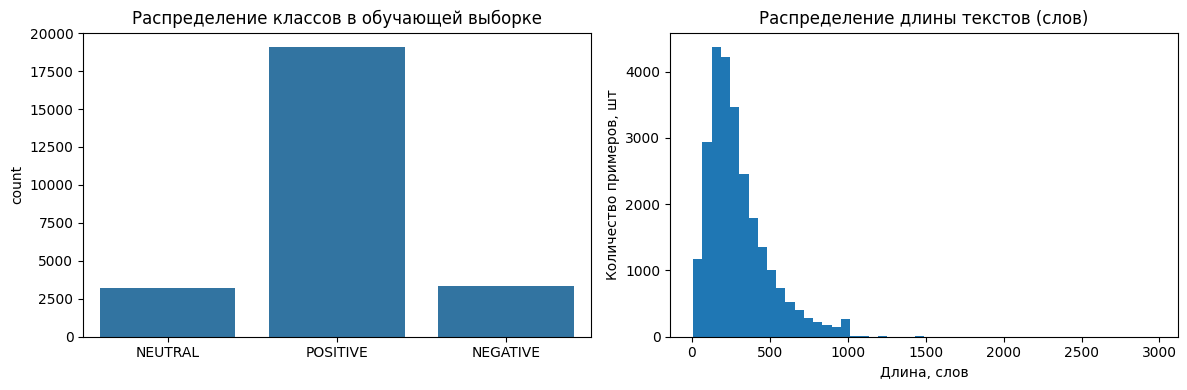

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Распределение классов в обучающей выборке')
axes[0].set_xticklabels(['NEUTRAL', 'POSITIVE', 'NEGATIVE'])

lengths = [len(text.split()) for text in X_train]
axes[1].hist(lengths, bins=50)
axes[1].set_title('Распределение длины текстов (слов)')
axes[1].set_xlabel('Длина, слов')
axes[1].set_ylabel('Количество примеров, шт')

plt.tight_layout()
plt.show()

**2. Baseline: TF‑IDF + логистическая регрессия**

Построим простую модель для сравнения. Векторизуем тексты с помощью TF‑IDF (униграммы + биграммы, максимум 10000 признаков) и обучим логистическую регрессию. Это даст нам нижнюю границу качества.

In [7]:
# В качестве токенов используются слова и их парные комбинации ngram_range=(1,2).
# Максимум слов в словаре на все комментарии будет 10000,  остальные будут отброшены (max_features=10000).

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_test_pred_lr = lr.predict(X_test_tfidf)
print("Baseline (LogReg + TF-IDF):")
print(classification_report(y_test, y_test_pred_lr, target_names=['NEUTRAL', 'POSITIVE', 'NEGATIVE']))
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")

Baseline (LogReg + TF-IDF):
              precision    recall  f1-score   support

     NEUTRAL       0.49      0.16      0.24       687
    POSITIVE       0.86      0.97      0.92      4090
    NEGATIVE       0.73      0.67      0.70       712

    accuracy                           0.83      5489
   macro avg       0.70      0.60      0.62      5489
weighted avg       0.80      0.83      0.80      5489

Accuracy: 0.8329


In [8]:
X_train_tfidf[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 120 stored elements and shape (1, 10000)>

In [9]:
feature_names = vectorizer.get_feature_names_out()
feature_names

array(['000', '10', '10 10', ..., 'ярче', 'ясно', 'ясно что'],
      dtype=object)

In [10]:
len(feature_names)

10000

**3. Подготовка данных для RuBERT**

Используем русскоязычную модель **DeepPavlov/rubert-base-cased**. Для экономии времени возьмём только 20% обучающих данных (около 7500 примеров), но в полной версии можно использовать всю выборку.

Создадим класс `SentimentDataset` для токенизации и паддинга текстов.

In [11]:
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Для ускорения возьмём подвыборку (20% от train)
sample_size = int(0.5 * len(X_train))
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_train_small = X_train[indices]
y_train_small = y_train[indices]

train_dataset = SentimentDataset(X_train_small, y_train_small, tokenizer)
val_dataset = SentimentDataset(X_val, y_val, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

**4. Загрузка модели RuBERT и настройка обучения**

Загрузим предобученную модель с классификационной головой на 3 класса. Используем `Trainer` из библиотеки Transformers. Параметры обучения: 2 эпохи, батч 16, оценка на валидации после каждой эпохи.

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=7,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy='epoch',          # ← замена evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to="none",
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.696398,0.551163,0.793041,0.687225,0.793041,0.734754
2,0.500022,0.585242,0.804700,0.744214,0.804700,0.754791
3,0.390056,0.639919,0.788304,0.763707,0.788304,0.774064
4,0.244965,0.786020,0.779195,0.759009,0.779195,0.760470
5,0.161315,1.285203,0.728730,0.787161,0.728730,0.750101
6,0.085115,1.377952,0.750956,0.778393,0.750956,0.751827
7,0.047674,1.535572,0.753143,0.778339,0.753143,0.754125


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=5607, training_loss=0.2953008641017957, metrics={'train_runtime': 3285.4666, 'train_samples_per_second': 27.284, 'train_steps_per_second': 1.707, 'total_flos': 5896503247993344.0, 'train_loss': 0.2953008641017957, 'epoch': 7.0})

**5. Оценка модели на тестовой выборке и сравнение с baseline**

In [14]:
test_metrics = trainer.evaluate(test_dataset)
print("RuBERT на тестовой выборке:")
print(test_metrics)

# Получим предсказания для теста
predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)

print("\nClassification report RuBERT:")
print(classification_report(y_test, y_pred_bert, target_names=['NEUTRAL', 'POSITIVE', 'NEGATIVE']))

print(f"\nAccuracy baseline (TF-IDF): {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"Accuracy RuBERT: {test_metrics['eval_accuracy']:.4f}")

RuBERT на тестовой выборке:
{'eval_loss': 0.5933224558830261, 'eval_accuracy': 0.8012388413190017, 'eval_precision': 0.7422941471061905, 'eval_recall': 0.8012388413190017, 'eval_f1': 0.7511879549185798, 'eval_runtime': 49.4317, 'eval_samples_per_second': 111.042, 'eval_steps_per_second': 3.48, 'epoch': 7.0}

Classification report RuBERT:
              precision    recall  f1-score   support

     NEUTRAL       0.33      0.02      0.04       687
    POSITIVE       0.83      0.97      0.90      4090
    NEGATIVE       0.61      0.60      0.60       712

    accuracy                           0.80      5489
   macro avg       0.59      0.53      0.51      5489
weighted avg       0.74      0.80      0.75      5489


Accuracy baseline (TF-IDF): 0.8329
Accuracy RuBERT: 0.8012


**6. Визуализация матрицы ошибок**

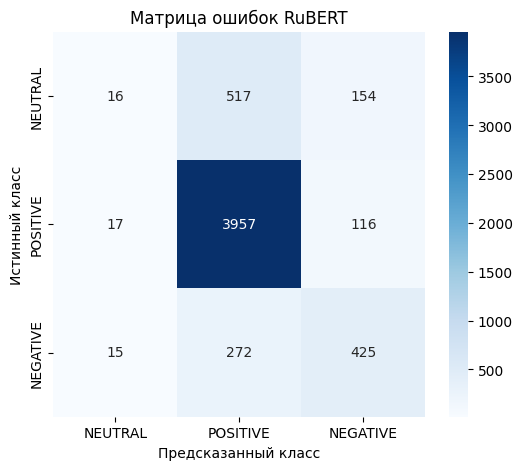

In [15]:
cm = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NEUTRAL', 'POSITIVE', 'NEGATIVE'], yticklabels=['NEUTRAL', 'POSITIVE', 'NEGATIVE'])
plt.title('Матрица ошибок RuBERT')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

**7. Инференс на новых примерах**

Теперь можно использовать обученную модель для классификации произвольных текстов. Создадим функцию, которая принимает текст и возвращает предсказанную тональность.

In [16]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128).to(device)
    model.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()
    return pred

sample_texts = [
    # про фильмы
    "Отличный фильм, очень понравился!",
    "Сценарий слабый, актёры играют деревянно, зря потратил время.",
    # рестораны
    "Вкусная паста, приятный официант, приду ещё.",
    "Ужасное обслуживание, больше не приду.",
    # техника
    "Наушники держат заряд весь день, звук чистый — рекомендую.",
    "Телефон глючит через неделю после покупки, кошмар.",
    # книги
    "Интересная книга, прочитал за вечер, сюжет затягивает.",
    # нейтральные
    "Нормально, ничего особенного.",
    "Доставка пришла в срок, упаковка целая.",
]

label_map = {0: 'NEUTRAL', 1: 'POSITIVE', 2: 'NEGATIVE'}
for text in sample_texts:
    pred = predict_sentiment(text)
    print(f"[{label_map[pred]}] {text[:80]}")

[POSITIVE] Отличный фильм, очень понравился!
[NEGATIVE] Сценарий слабый, актёры играют деревянно, зря потратил время.
[NEUTRAL] Вкусная паста, приятный официант, приду ещё.
[NEGATIVE] Ужасное обслуживание, больше не приду.
[POSITIVE] Наушники держат заряд весь день, звук чистый — рекомендую.
[NEGATIVE] Телефон глючит через неделю после покупки, кошмар.
[POSITIVE] Интересная книга, прочитал за вечер, сюжет затягивает.
[NEUTRAL] Нормально, ничего особенного.
[POSITIVE] Доставка пришла в срок, упаковка целая.


**8. (Опционально) Демонстрация генерации текста с помощью GPT‑2**

Для иллюстрации работы декодерной модели используем предобученную GPT‑2 (маленькую версию) и сгенерируем продолжение текста. Это поможет понять разницу между BERT (понимание) и GPT (генерация).

In [17]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

gpt_model_name = "sberbank-ai/rugpt3small_based_on_gpt2"  # небольшая русскоязычная GPT
gpt_tokenizer = GPT2Tokenizer.from_pretrained(gpt_model_name)
gpt_model = GPT2LMHeadModel.from_pretrained(gpt_model_name)

gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

prompt = "Сегодня я решил попробовать новый ресторан"
inputs = gpt_tokenizer(prompt, return_tensors='pt')

output = gpt_model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    pad_token_id=gpt_tokenizer.eos_token_id
)

generated_text = gpt_tokenizer.decode(output[0], skip_special_tokens=True)
print("Промпт:", prompt)
print("Сгенерированный текст:", generated_text)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Промпт: Сегодня я решил попробовать новый ресторан
Сгенерированный текст: Сегодня я решил попробовать новый ресторан с необычным названием.  Это ресторан с необычным названием, у которого есть и название, и меню.  Он очень уютный, а порции очень большие.  Но, конечно же, здесь не обошлось без сюрпризов.  К примеру, когда мы


**9. Выводы**

В этом практическом занятии мы:
*   Загрузили и проанализировали датасет русскоязычных отзывов.
*   Построили базовую модель на TF‑IDF и логистической регрессии.
*   Тонко настроили модель RuBERT для классификации тональности.
*   Сравнили качество: трансформеры значительно превосходят простые методы.
*   Попробовали генерировать текст с помощью GPT‑2.

**Важные замечания:**
*   Для ускорения обучения мы использовали только 20% обучающих данных. При использовании всей выборки качество может быть выше.
*   Для русскоязычных задач важно выбирать модели, обученные на русском языке (RuBERT, ruGPT и др.).
*   Трансформеры требуют больше вычислительных ресурсов, но обеспечивают гораздо лучшее качество.

Теперь вы можете применить эти техники к своим данным в рамках финального проекта!

**Задания:**
1. Попробовать большее количество эпох.
2. Попробовать добавить другие отзывы о фильмах или не только о фильмах.
3. Попробовать использовать более объёмный набор данных или свой по интересу или из ВКРМ.

**Заключение:**
1. Новые навыки/умения/знания.
2. Пожелания по содержимому лекционного и практического блокнотов, по способу предоставления материала.
